## 1. Intro

1. To get started, please write 5 examples of the application of ML methods in life. What is the benefit of using machine learning methods in each of your examples? 

    1. Предсказание успешности малого бизнеса, по фичам по типу (место, сфера, вложения и тп)
    - Можно избежать плохих трат и не открывать шаурму в неудачном месте
    классификация (разделить на уровни успешности, или бинарная), регрессия, кластеризация(опасно)
    2. Алгоритмы всех соцсетей
    - Создают идеальную подборку, идеальную ленту. Ускоряют поиск нужной(а может и просто желаемой) информации, выполняя рутину за нас
    классификация, ассоциативные модели, кластеризация
    3. Сортировка почты
    - Закидывает ненужное в спам, спасая нас от тонны ненужных писем
    классификация
    4. Рассчет времени пути в навигаторе
    - Примерно считает сколько времени уйдет на дорогу вместо нас, позволяя не думать об этом
    регрессия
    5. Рассчет финансовых рисков (инвестиций)
    - Математически прикидывает риски, позволяя снизить вероятность потерять деньги
    classification (label, binary, class) / regression

2. Use the classification of tasks in the introduction to decide which class you can assign to the tasks from the table above and to the 5 examples you provided.   

    - *Задача T - класс задачи*  
 1  Прогнозировать цену дома - Регрессия sv  
 2  Прогнозировать, вернёт ли клиент кредит - binary классификация sv  
 3  Предсказать, когда пациенту нужно принять лекарство - Регрессия sv  
 4  Выбрать лекарство из доступных, которое должен принять пациент - multiclass классификация sv  
 5  Выбрать сегмент клиентов для промо-коммуникации - кластеризация usv  
 6  Распознать брак на конвейере по фото - binary Классификация sv  
 7  Определить выкладку товаров на полке магазина - регрессия sv  
 8  Подобрать сайты по текстовому запросу - multilabel Классификация sv  
 9  Разбить покупателей магазина на сегменты, чтобы понять различия в поведении - Кластеризация usv  
 10  Обнаружить аномалию в трафике сайта - Снижение размерности (dimensionality reduction)  usv + классификация sv


3. Think about what the difference is between multiclass and multilabel.
    - Мултиклассовая - один элемент - один класс  
МультиТег (label) - один элемент - несколько тегов

4. Is an example case with house prices from the theory a classification of a regression problem? Is it possible to reduce the regression problem to classification?    
   - Я думаю да, мы можем придумать несколько категорий цен, но тогда по ним нкжно и разметить данные, что займет дополнительное время. И не факт что подойдет под все задачи. Сложно прикинуть это будет оптимизацией процесса или только усложнит его.

## 2. Data download

In [1]:
import pandas as pd
import seaborn as sns
import numpy as np
from sklearn.preprocessing import PolynomialFeatures
pd.options.display.float_format = '{:.2f}'.format

In [2]:
df = pd.read_json('data/train.json')

In [3]:
df.head()

,bathrooms,bedrooms,building_id,created,description,display_address,features,latitude,listing_id,longitude,manager_id,photos,price,street_address,interest_level
4,1.00,1,8579a0b0d54db803821a35a4a615e97a,2016-06-16 05:55:27,Spacious 1 Bedroom 1 Bathroom in Williamsburg!...,145 Borinquen Place,"[Dining Room, Pre-War, Laundry in Building, Di...",40.71,7170325,-73.95,a10db4590843d78c784171a107bdacb4,[https://photos.renthop.com/2/7170325_3bb5ac84...,2400,145 Borinquen Place,medium
6,1.00,2,b8e75fc949a6cd8225b455648a951712,2016-06-01 05:44:33,BRAND NEW GUT RENOVATED TRUE 2 BEDROOMFind you...,East 44th,"[Doorman, Elevator, Laundry in Building, Dishw...",40.75,7092344,-73.97,955db33477af4f40004820b4aed804a0,[https://photos.renthop.com/2/7092344_7663c19a...,3800,230 East 44th,low
9,1.00,2,cd759a988b8f23924b5a2058d5ab2b49,2016-06-14 15:19:59,**FLEX 2 BEDROOM WITH FULL PRESSURIZED WALL**L...,East 56th Street,"[Doorman, Elevator, Laundry in Building, Laund...",40.76,7158677,-73.96,c8b10a317b766204f08e613cef4ce7a0,[https://photos.renthop.com/2/7158677_c897a134...,3495,405 East 56th Street,medium
10,1.50,3,53a5b119ba8f7b61d4e010512e0dfc85,2016-06-24 07:54:24,A Brand New 3 Bedroom 1.5 bath ApartmentEnjoy ...,Metropolitan Avenue,[],40.71,7211212,-73.94,5ba989232d0489da1b5f2c45f6688adc,[https://photos.renthop.com/2/7211212_1ed4542e...,3000,792 Metropolitan Avenue,medium
15,1.00,0,bfb9405149bfff42a92980b594c28234,2016-06-28 03:50:23,Over-sized Studio w abundant closets. Availabl...,East 34th Street,"[Doorman, Elevator, Fitness Center, Laundry in...",40.74,7225292,-73.97,2c3b41f588fbb5234d8a1e885a436cfa,[https://photos.renthop.com/2/7225292_901f1984...,2795,340 East 34th Street,low


In [4]:
df.info()

<class 'pandas.DataFrame'>
Index: 49352 entries, 4 to 124009
Data columns (total 15 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   bathrooms        49352 non-null  float64
 1   bedrooms         49352 non-null  int64  
 2   building_id      49352 non-null  str    
 3   created          49352 non-null  str    
 4   description      49352 non-null  str    
 5   display_address  49352 non-null  str    
 6   features         49352 non-null  object 
 7   latitude         49352 non-null  float64
 8   listing_id       49352 non-null  int64  
 9   longitude        49352 non-null  float64
 10  manager_id       49352 non-null  str    
 11  photos           49352 non-null  object 
 12  price            49352 non-null  int64  
 13  street_address   49352 non-null  str    
 14  interest_level   49352 non-null  str    
dtypes: float64(3), int64(3), object(2), str(7)
memory usage: 6.0+ MB


15 колонок, 49352 строк.  
Таргет. - price

In [5]:
df.describe()

,bathrooms,bedrooms,latitude,listing_id,longitude,price
count,49352.00,49352.00,49352.00,49352.00,49352.00,49352.00
mean,1.21,1.54,40.74,7024054.66,-73.96,3830.17
std,0.50,1.12,0.64,126274.61,1.18,22066.87
min,0.00,0.00,0.00,6811957.00,-118.27,43.00
25%,1.00,1.00,40.73,6915887.50,-73.99,2500.00
50%,1.00,1.00,40.75,7021070.50,-73.98,3150.00
75%,1.00,2.00,40.77,7128733.25,-73.95,4100.00
max,10.00,8.00,44.88,7753784.00,0.00,4490000.00


In [6]:
non_str = df.select_dtypes(include='number')
non_str.corr()

,bathrooms,bedrooms,latitude,listing_id,longitude,price
bathrooms,1.00,0.53,-0.01,0.00,0.01,0.07
bedrooms,0.53,1.00,-0.00,0.01,0.01,0.05
latitude,-0.01,-0.00,1.00,0.00,-0.97,-0.00
listing_id,0.00,0.01,0.00,1.00,-0.00,0.01
longitude,0.01,0.01,-0.97,-0.00,1.00,-0.00
price,0.07,0.05,-0.00,0.01,-0.00,1.00


In [7]:
df.isna().sum()

bathrooms          0
bedrooms           0
building_id        0
created            0
description        0
display_address    0
features           0
latitude           0
listing_id         0
longitude          0
manager_id         0
photos             0
price              0
street_address     0
interest_level     0
dtype: int64

In [8]:
df

,bathrooms,bedrooms,building_id,created,description,display_address,features,latitude,listing_id,longitude,manager_id,photos,price,street_address,interest_level
4,1.00,1,8579a0b0d54db803821a35a4a615e97a,2016-06-16 05:55:27,Spacious 1 Bedroom 1 Bathroom in Williamsburg!...,145 Borinquen Place,"[Dining Room, Pre-War, Laundry in Building, Di...",40.71,7170325,-73.95,a10db4590843d78c784171a107bdacb4,[https://photos.renthop.com/2/7170325_3bb5ac84...,2400,145 Borinquen Place,medium
6,1.00,2,b8e75fc949a6cd8225b455648a951712,2016-06-01 05:44:33,BRAND NEW GUT RENOVATED TRUE 2 BEDROOMFind you...,East 44th,"[Doorman, Elevator, Laundry in Building, Dishw...",40.75,7092344,-73.97,955db33477af4f40004820b4aed804a0,[https://photos.renthop.com/2/7092344_7663c19a...,3800,230 East 44th,low
9,1.00,2,cd759a988b8f23924b5a2058d5ab2b49,2016-06-14 15:19:59,**FLEX 2 BEDROOM WITH FULL PRESSURIZED WALL**L...,East 56th Street,"[Doorman, Elevator, Laundry in Building, Laund...",40.76,7158677,-73.96,c8b10a317b766204f08e613cef4ce7a0,[https://photos.renthop.com/2/7158677_c897a134...,3495,405 East 56th Street,medium
10,1.50,3,53a5b119ba8f7b61d4e010512e0dfc85,2016-06-24 07:54:24,A Brand New 3 Bedroom 1.5 bath ApartmentEnjoy ...,Metropolitan Avenue,[],40.71,7211212,-73.94,5ba989232d0489da1b5f2c45f6688adc,[https://photos.renthop.com/2/7211212_1ed4542e...,3000,792 Metropolitan Avenue,medium
15,1.00,0,bfb9405149bfff42a92980b594c28234,2016-06-28 03:50:23,Over-sized Studio w abundant closets. Availabl...,East 34th Street,"[Doorman, Elevator, Fitness Center, Laundry in...",40.74,7225292,-73.97,2c3b41f588fbb5234d8a1e885a436cfa,[https://photos.renthop.com/2/7225292_901f1984...,2795,340 East 34th Street,low
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
124000,1.00,3,92bbbf38baadfde0576fc496bd41749c,2016-04-05 03:58:33,There is 700 square feet of recently renovated...,W 171 Street,"[Elevator, Dishwasher, Hardwood Floors]",40.84,6824800,-73.94,a61e21da3ba18c7a3d54cfdcc247e1f8,[https://photos.renthop.com/2/6824800_0682be16...,2800,620 W 171 Street,low
124002,1.00,2,5565db9b7cba3603834c4aa6f2950960,2016-04-02 02:25:31,"2 bedroom apartment with updated kitchen, rece...",Broadway,"[Common Outdoor Space, Cats Allowed, Dogs Allo...",40.82,6813268,-73.96,8f90e5e10e8a2d7cf997f016d89230eb,[https://photos.renthop.com/2/6813268_1e6fcc32...,2395,3333 Broadway,medium
124004,1.00,1,67997a128056ee1ed7d046bbb856e3c7,2016-04-26 05:42:03,No Brokers Fee * Never Lived 1 Bedroom 1 Bathr...,210 Brighton 15th St,"[Dining Room, Elevator, Pre-War, Laundry in Bu...",40.58,6927093,-73.96,a10db4590843d78c784171a107bdacb4,[https://photos.renthop.com/2/6927093_93a52104...,1850,210 Brighton 15th St,medium
124008,1.00,2,3c0574a740154806c18bdf1fddd3d966,2016-04-19 02:47:33,Wonderful Bright Chelsea 2 Bedroom apartment o...,West 21st Street,"[Pre-War, Laundry in Unit, Dishwasher, No Fee,...",40.74,6892816,-74.00,c3cd45f4381ac371507090e9ffabea80,[https://photos.renthop.com/2/6892816_1a8d087a...,4195,350 West 21st Street,medium


In [9]:
data = df[['bathrooms', 'bedrooms', 'interest_level', 'price']].copy()
data.head()

,bathrooms,bedrooms,interest_level,price
4,1.00,1,medium,2400
6,1.00,2,low,3800
9,1.00,2,medium,3495
10,1.50,3,medium,3000
15,1.00,0,low,2795


## 3. Statistical Data Analysis

### Target Analysis

In [10]:
data.price.describe()

count     49352.00
mean       3830.17
std       22066.87
min          43.00
25%        2500.00
50%        3150.00
75%        4100.00
max     4490000.00
Name: price, dtype: float64

In [11]:
data.price.value_counts()

price
2500      1106
3200       881
3000       840
2700       777
2400       772
          ... 
15850        1
11340        1
3261         1
2891         1
135000       1
Name: count, Length: 2808, dtype: int64

<Axes: >

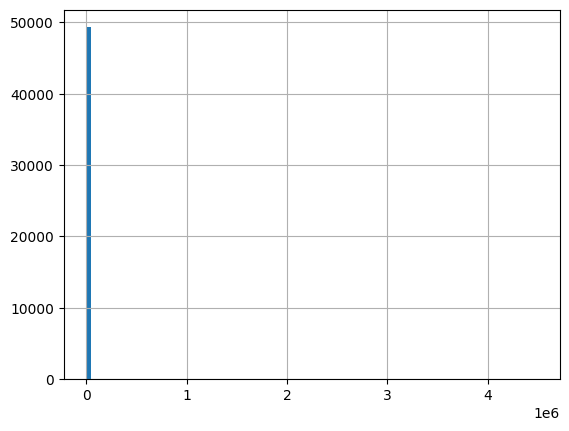

In [12]:
data.price.hist(bins=100)

На этом графике мы видим, что у нас примерно 2500 уникальных цен встречаются от 0 до 100 раз. (а если точнее, то встречаются 1 раз).  
А так же, что у нас сильный перекос данных. Есть редкие и сильные выбросы, из-за чего большая часть значений попадает в один бин

<Axes: >

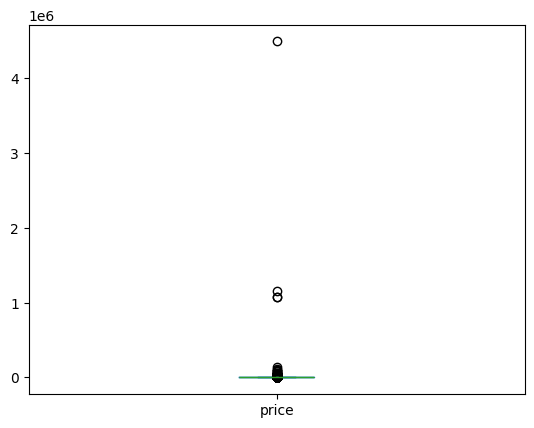

In [13]:
data.price.plot.box()

еще лучше видно как плохо распределены данные

In [14]:
data.price.max()

np.int64(4490000)

In [15]:
l, r = data.price.quantile([0.01, 0.99])

In [16]:
test = data.loc[data.price>=r]
test.price.sort_values()

107843      13000
48847       13000
6213        13000
84318       13000
7190        13000
           ...   
123877     135000
55437     1070000
57803     1070000
12168     1150000
32611     4490000
Name: price, Length: 502, dtype: int64

In [17]:
data = data.loc[(data.price>=l)&(data.price<=r)]

<Axes: >

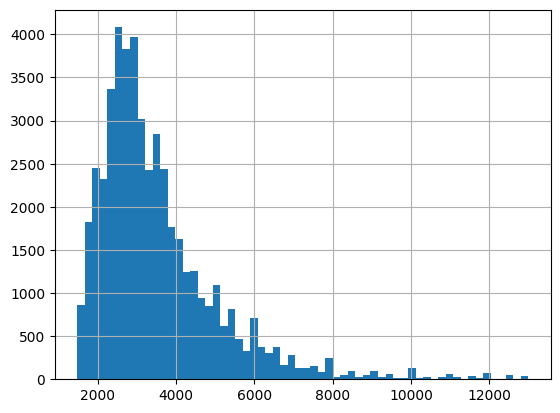

In [18]:
data.price.hist(bins=60)

После отсечения выбросов - видим более красивую картинку того, сколько раз встречается какая цена.  
Самые частые цены кстати 2500-3000. (Было легче мосчитать их как ниже, но та не видно было бы кривого распределения)

<Axes: xlabel='price', ylabel='Density'>

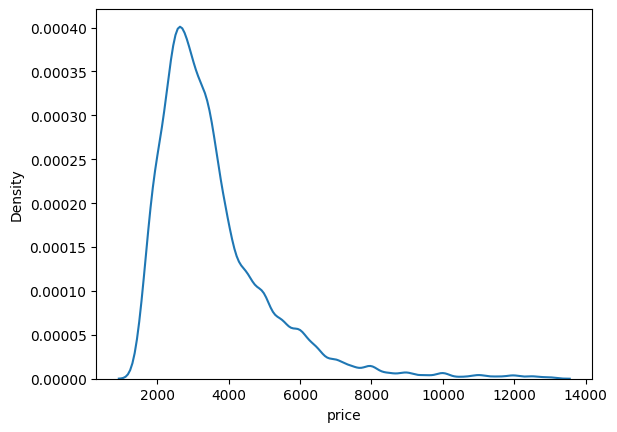

In [19]:
sns.kdeplot(data.price)

<Axes: ylabel='price'>

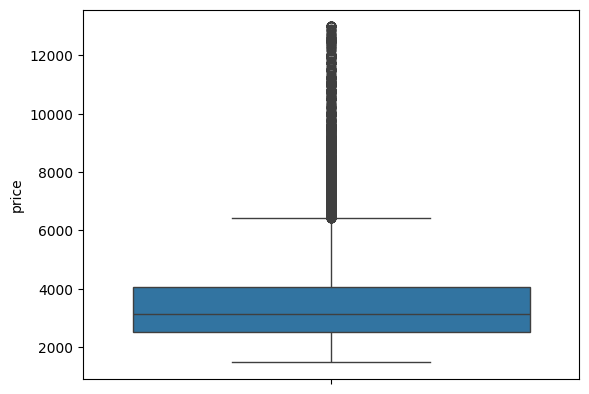

In [20]:
sns.boxplot(data.price)

In [21]:
data.price.value_counts()

price
2500     1106
3200      881
3000      840
2700      777
2400      772
         ... 
8115        1
4858        1
11340       1
3261        1
2891        1
Name: count, Length: 2635, dtype: int64

### Characeteristics Analysis

In [22]:
data.interest_level

4         medium
6            low
9         medium
10        medium
15           low
           ...  
124000       low
124002    medium
124004    medium
124008    medium
124009      high
Name: interest_level, Length: 48379, dtype: str

In [23]:
gr = data.interest_level.value_counts()
gr

interest_level
low       33697
medium    11116
high       3566
Name: count, dtype: int64

<Axes: xlabel='interest_level'>

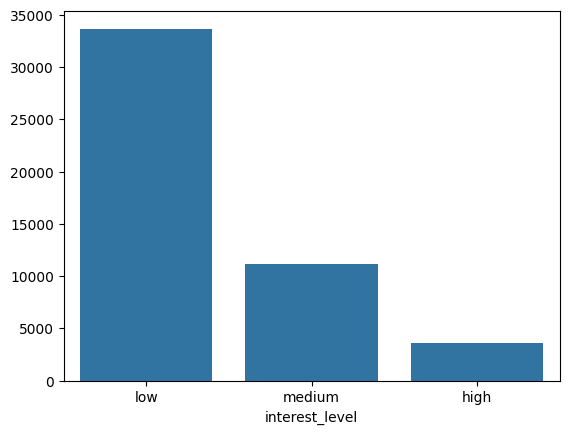

In [24]:
sns.barplot(x = gr.index, y = gr.values)

In [25]:
data.interest_level = data.interest_level.replace('low', 0)
data.interest_level = data.interest_level.replace('medium', 1)
data.interest_level = data.interest_level.replace('high', 2)
data.interest_level.head()

4     1
6     0
9     1
10    1
15    0
Name: interest_level, dtype: object

In [26]:
data.interest_level

4         1
6         0
9         1
10        1
15        0
         ..
124000    0
124002    1
124004    1
124008    1
124009    2
Name: interest_level, Length: 48379, dtype: object

<Axes: >

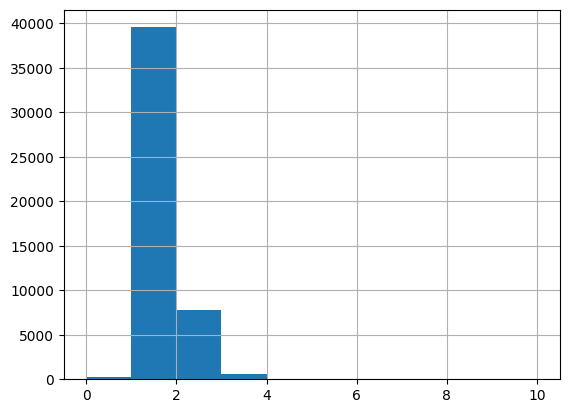

In [27]:
data.bathrooms.hist()

<Axes: >

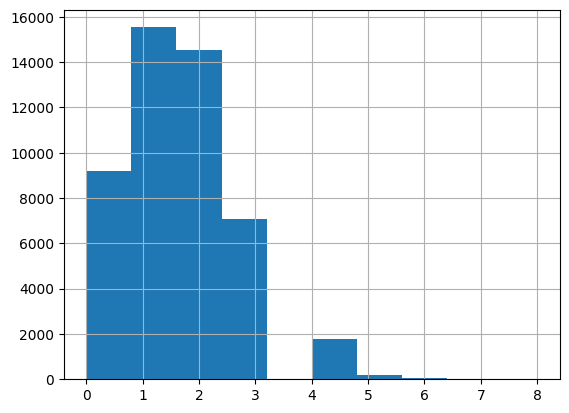

In [28]:
data.bedrooms.hist()

### Complex analysis

In [29]:
data.corr()

,bathrooms,bedrooms,interest_level,price
bathrooms,1.00,0.52,-0.06,0.67
bedrooms,0.52,1.00,0.05,0.55
interest_level,-0.06,0.05,1.00,-0.20
price,0.67,0.55,-0.20,1.00


<Axes: xlabel='price', ylabel='bathrooms'>

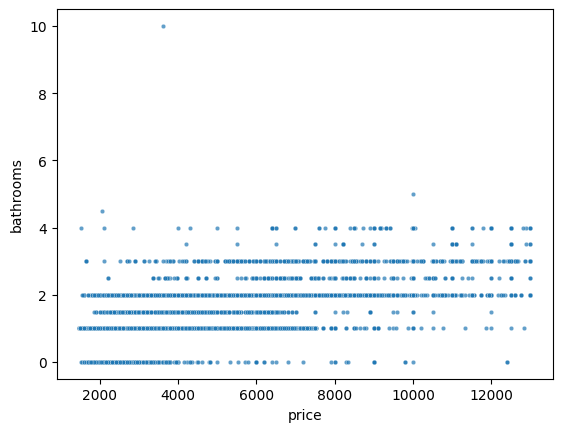

In [30]:
sns.scatterplot(data=data, x=data.price, y = data.bathrooms, alpha = 0.7, s = 10)

<Axes: xlabel='price', ylabel='bedrooms'>

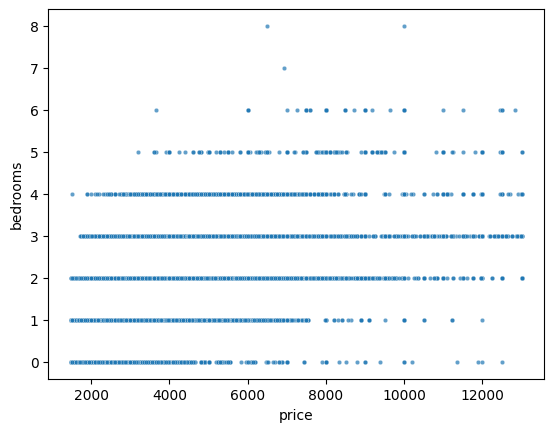

In [31]:
sns.scatterplot(data=data, x=data.price, y = data.bedrooms, alpha = 0.7, s = 10)

<Axes: xlabel='price', ylabel='interest_level'>

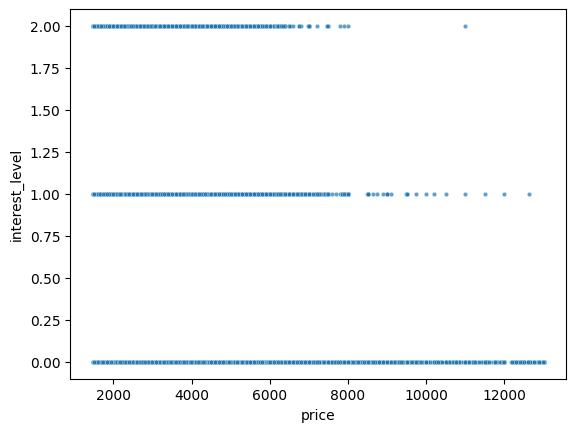

In [32]:
sns.scatterplot(data=data, x=data.price, y = data.interest_level, alpha = 0.7, s = 10)

## 4. Creating Features

In [33]:
square = data.copy()
square["bathrooms_sq"] = square.bathrooms**2
square["bedrooms_sq"] = square.bedrooms**2
square["interest_level_sq"] = square.interest_level**2
square.corr()

,bathrooms,bedrooms,interest_level,price,bathrooms_sq,bedrooms_sq,interest_level_sq
bathrooms,1.00,0.52,-0.06,0.67,0.96,0.55,-0.06
bedrooms,0.52,1.00,0.05,0.55,0.48,0.93,0.04
interest_level,-0.06,0.05,1.00,-0.20,-0.07,0.05,0.94
price,0.67,0.55,-0.20,1.00,0.65,0.54,-0.18
bathrooms_sq,0.96,0.48,-0.07,0.65,1.00,0.52,-0.06
bedrooms_sq,0.55,0.93,0.05,0.54,0.52,1.00,0.04
interest_level_sq,-0.06,0.04,0.94,-0.18,-0.06,0.04,1.00


<Axes: >

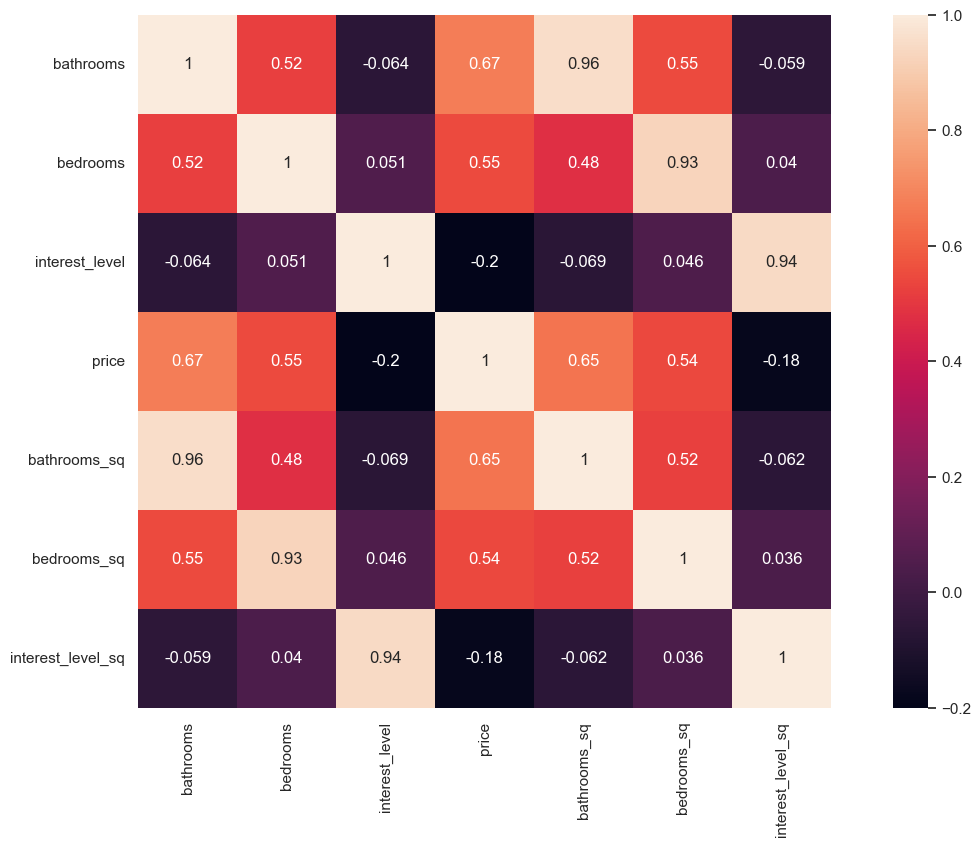

In [34]:
sns.set_theme(rc={'figure.figsize':(16,9)})
sns.heatmap(square.corr(), cmap = "rocket", annot=True, square=True)

In [35]:
df_test = pd.read_json("data/test.json")
test = df_test[['bathrooms', 'bedrooms', 'price']].copy()
# test.interest_level = test.interest_level.replace('low', 0)
# test.interest_level = test.interest_level.replace('medium', 1)
# test.interest_level = test.interest_level.replace('high', 2)
# test["bathrooms_sq"] = test.bathrooms**2
# test["bedrooms_sq"] = test.bedrooms**2
# test["interest_level_sq"] = test.interest_level**2
test.head()

,bathrooms,bedrooms,price
0,1.00,1,2950
1,1.00,2,2850
2,1.00,0,2295
3,1.00,2,2900
5,1.00,1,3254


split

In [36]:
df_test.info()

<class 'pandas.DataFrame'>
Index: 74659 entries, 0 to 124010
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   bathrooms        74659 non-null  float64
 1   bedrooms         74659 non-null  int64  
 2   building_id      74659 non-null  str    
 3   created          74659 non-null  str    
 4   description      74659 non-null  str    
 5   display_address  74659 non-null  str    
 6   features         74659 non-null  object 
 7   latitude         74659 non-null  float64
 8   listing_id       74659 non-null  int64  
 9   longitude        74659 non-null  float64
 10  manager_id       74659 non-null  str    
 11  photos           74659 non-null  object 
 12  price            74659 non-null  int64  
 13  street_address   74659 non-null  str    
dtypes: float64(3), int64(3), object(2), str(6)
memory usage: 8.5+ MB


In [37]:
from sklearn.model_selection import train_test_split

In [38]:
X = data.drop(columns=['price', 'interest_level'])
y = data.price
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.33, random_state=21)

In [39]:
data.info()

<class 'pandas.DataFrame'>
Index: 48379 entries, 4 to 124009
Data columns (total 4 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   bathrooms       48379 non-null  float64
 1   bedrooms        48379 non-null  int64  
 2   interest_level  48379 non-null  object 
 3   price           48379 non-null  int64  
dtypes: float64(1), int64(2), object(1)
memory usage: 1.8+ MB


<Axes: xlabel='bathrooms', ylabel='Count'>

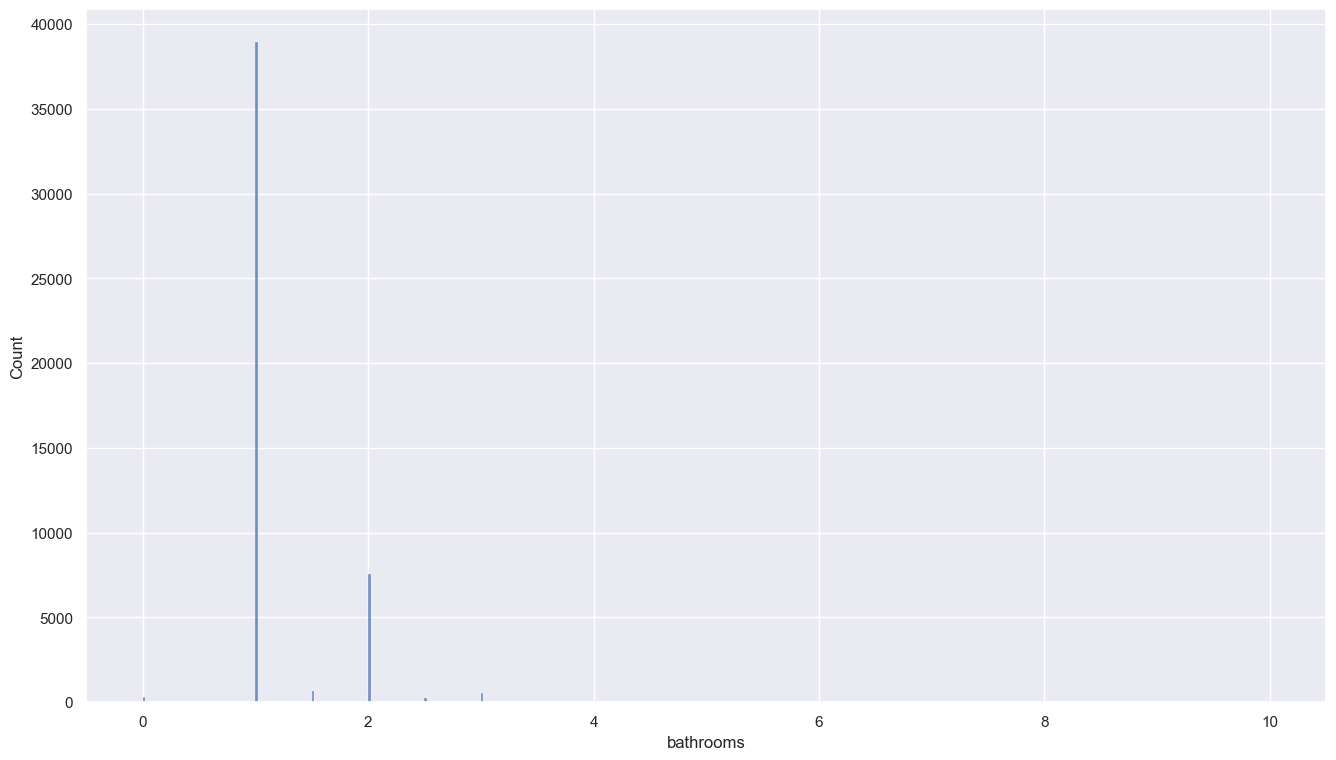

In [40]:
sns.histplot(data.bathrooms)

In [41]:
# X_train = data.drop(columns=['price', 'interest_level'])
# y_train = data.price
# X_test = test.drop(columns='price')
# y_test = test.price

In [42]:
X_test.head()

,bathrooms,bedrooms
3230,1.00,2
94946,1.00,0
75895,1.00,0
33174,1.00,1
123977,1.00,1


In [43]:
X_train.head()

,bathrooms,bedrooms
94375,1.00,2
56848,1.00,0
42115,1.00,1
91589,1.00,1
16432,1.00,4


In [44]:
y_train.head()

94375    3300
56848    1900
42115    2850
91589    2990
16432    3600
Name: price, dtype: int64

In [45]:
y_test.head()

3230      2850
94946     2400
75895     2550
33174     2400
123977    3795
Name: price, dtype: int64

In [46]:
poly = PolynomialFeatures(degree=10, interaction_only=True)
poly_train = poly.fit_transform(X_train)
poly_train

array([[1., 1., 2., 2.],
       [1., 1., 0., 0.],
       [1., 1., 1., 1.],
       ...,
       [1., 2., 3., 6.],
       [1., 1., 1., 1.],
       [1., 1., 1., 1.]], shape=(32413, 4))

In [47]:
poly_test = poly.transform(X_test)
poly_test

array([[1., 1., 2., 2.],
       [1., 1., 0., 0.],
       [1., 1., 0., 0.],
       ...,
       [1., 1., 1., 1.],
       [1., 2., 2., 4.],
       [1., 1., 2., 2.]], shape=(15966, 4))

In [48]:
X_pt = pd.DataFrame(poly_train)
X_pt

,0,1,2,3
0,1.00,1.00,2.00,2.00
1,1.00,1.00,0.00,0.00
2,1.00,1.00,1.00,1.00
3,1.00,1.00,1.00,1.00
4,1.00,1.00,4.00,4.00
...,...,...,...,...
32408,1.00,2.00,3.00,6.00
32409,1.00,1.00,2.00,2.00
32410,1.00,2.00,3.00,6.00
32411,1.00,1.00,1.00,1.00


In [49]:
X_pt.describe()

,0,1,2,3
count,32413.00,32413.00,32413.00,32413.00
mean,1.00,1.19,1.54,2.10
std,0.00,0.46,1.10,2.22
min,1.00,0.00,0.00,0.00
25%,1.00,1.00,1.00,1.00
50%,1.00,1.00,1.00,1.00
75%,1.00,1.00,2.00,3.00
max,1.00,10.00,7.00,30.00


In [50]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
# poly_train = scaler.fit_transform(poly_train)
# poly_test = scaler.transform(poly_test)

## 5. Обучение 3х моделей

In [51]:
result_MAE = pd.DataFrame(columns=['model', 'train', 'test'])
result_RMSE = pd.DataFrame(columns=['model', 'train', 'test'])

In [52]:
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import root_mean_squared_error

### Linear Regression

In [53]:
from sklearn.linear_model import LinearRegression

In [54]:
model_lr = LinearRegression()
model_lr.fit(poly_train, y_train)
y_pred = model_lr.predict(poly_test)
y_train_pred = model_lr.predict(poly_train)
y_pred

array([3354.81627795, 2588.92753231, 2588.92753231, ..., 2971.87190513,
       5179.77792929, 3354.81627795], shape=(15966,))

In [55]:
model_lr.coef_.mean()

np.float64(518.6607605635894)

In [56]:
result_MAE.loc[0] = 'LinearRegression', mean_absolute_error(y_train, y_train_pred), mean_absolute_error(y_test, y_pred)
result_MAE

,model,train,test
0,LinearRegression,786.17,784.16


In [57]:
result_RMSE.loc[0] = 'LinearRegression', root_mean_squared_error(y_train, y_train_pred), root_mean_squared_error(y_test, y_pred)
result_RMSE

,model,train,test
0,LinearRegression,1125.63,1119.78


In [58]:
from sklearn import linear_model
model_lasso = linear_model.Lasso(alpha=0.6)
model_lasso.fit(poly_train, y_train)
y_pred = model_lasso.predict(poly_test)
y_train_pred = model_lasso.predict(poly_train)
y_pred

array([3354.88358132, 2590.32690287, 2590.32690287, ..., 2972.6052421 ,
       5172.82759746, 3354.88358132], shape=(15966,))

In [59]:
model_lasso.coef_.mean()

np.float64(513.7865387823961)

In [60]:
result_MAE.loc[1] = 'Lasso', mean_absolute_error(y_train, y_train_pred), mean_absolute_error(y_test, y_pred)
result_RMSE.loc[1] = 'Lasso', root_mean_squared_error(y_train, y_train_pred), root_mean_squared_error(y_test, y_pred)
result_MAE

,model,train,test
0,LinearRegression,786.17,784.16
1,Lasso,786.17,784.21


In [61]:
result_RMSE

,model,train,test
0,LinearRegression,1125.63,1119.78
1,Lasso,1125.64,1119.85


In [62]:
from sklearn import linear_model
model_lasso = linear_model.ElasticNet()
model_lasso.fit(poly_train, y_train)
y_pred = model_lasso.predict(poly_test)
y_train_pred = model_lasso.predict(poly_train)
y_pred

array([3486.9672381 , 2602.28893394, 2602.28893394, ..., 3044.62808602,
       4482.31871179, 3486.9672381 ], shape=(15966,))

In [63]:
result_MAE.loc[2] = 'El', mean_absolute_error(y_train, y_train_pred), mean_absolute_error(y_test, y_pred)
result_RMSE.loc[2] = 'El', root_mean_squared_error(y_train, y_train_pred), root_mean_squared_error(y_test, y_pred)
result_MAE

,model,train,test
0,LinearRegression,786.17,784.16
1,Lasso,786.17,784.21
2,El,803.35,800.30


In [64]:
result_RMSE

,model,train,test
0,LinearRegression,1125.63,1119.78
1,Lasso,1125.64,1119.85
2,El,1162.39,1157.29


### Desicion Tree

In [65]:
from sklearn.tree import DecisionTreeRegressor

In [66]:
model_tree = DecisionTreeRegressor(random_state=21, max_depth=999)
model_tree.fit(X_train, y_train)
y_pred = model_tree.predict(X_test)
y_train_pred = model_tree.predict(X_train)
y_pred

array([3206.6622813 , 2472.84065373, 2472.84065373, ..., 3039.08088599,
       5409.88958991, 3206.6622813 ], shape=(15966,))

In [67]:
result_MAE.loc[len(result_MAE)] = 'Tree', mean_absolute_error(y_train, y_train_pred), mean_absolute_error(y_test, y_pred)
result_RMSE.loc[len(result_RMSE)] = 'Tree', root_mean_squared_error(y_train, y_train_pred), root_mean_squared_error(y_test, y_pred)
result_MAE

,model,train,test
0,LinearRegression,786.17,784.16
1,Lasso,786.17,784.21
2,El,803.35,800.30
3,Tree,755.54,758.11


In [68]:
result_RMSE

,model,train,test
0,LinearRegression,1125.63,1119.78
1,Lasso,1125.64,1119.85
2,El,1162.39,1157.29
3,Tree,1074.66,1086.31


<Axes: ylabel='Count'>

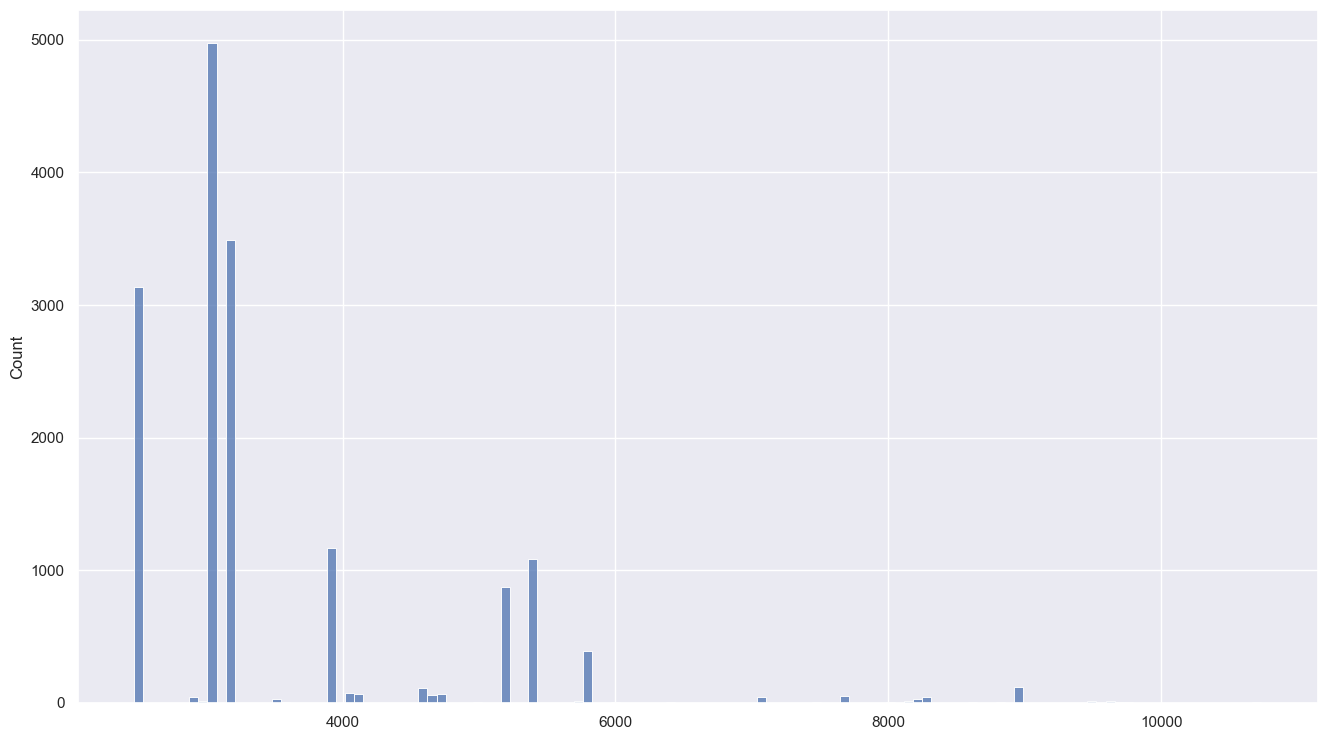

In [69]:
sns.histplot(data=y_pred)

<Axes: xlabel='price', ylabel='Count'>

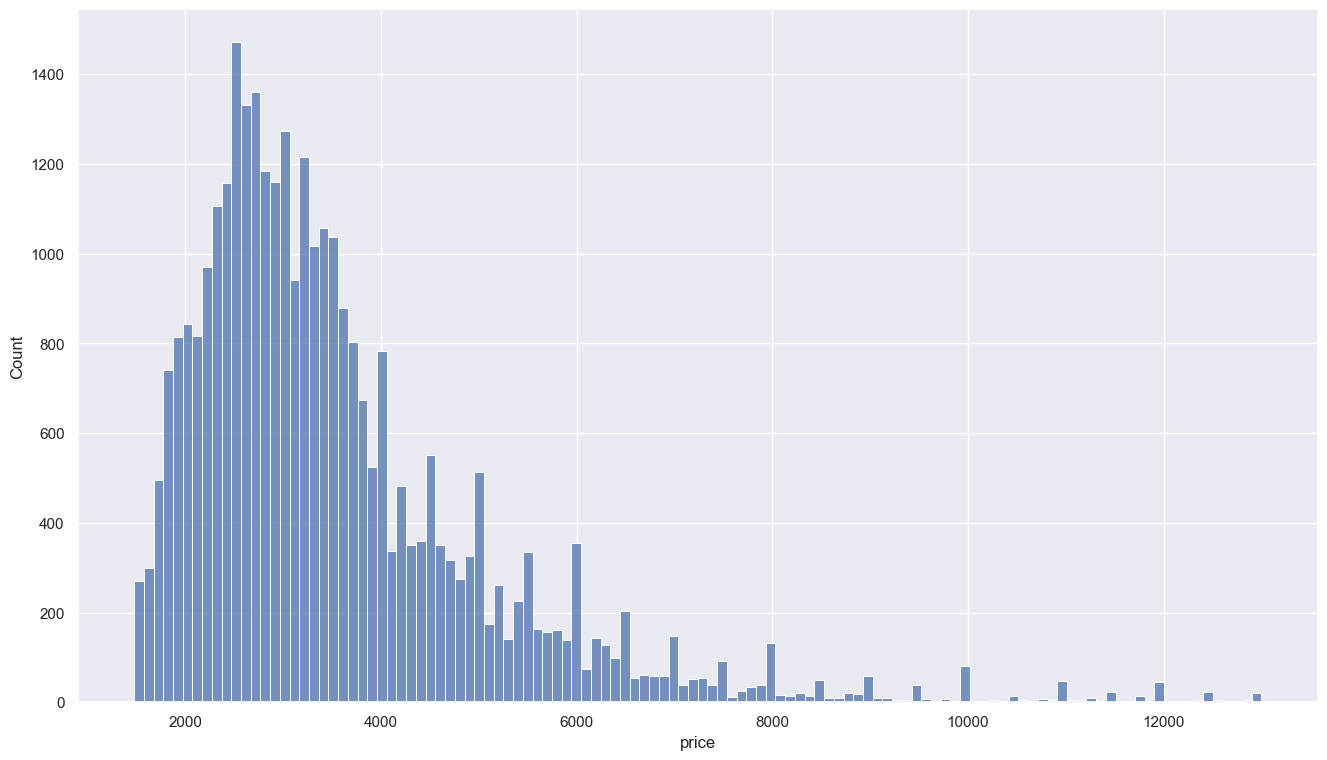

In [70]:
sns.histplot(y_train)

In [71]:
from sklearn.tree import plot_tree

[Text(0.37354910714285716, 0.9545454545454546, 'x[0] <= 1.75\nsquared_error = 2559640.535\nsamples = 32413\nvalue = 3546.673'),
 Text(0.18392857142857144, 0.8636363636363636, 'x[1] <= 2.5\nsquared_error = 965477.544\nsamples = 26700\nvalue = 3076.476'),
 Text(0.2787388392857143, 0.9090909090909092, 'True  '),
 Text(0.08928571428571429, 0.7727272727272727, 'x[1] <= 0.5\nsquared_error = 806095.285\nsamples = 23812\nvalue = 2965.0'),
 Text(0.02857142857142857, 0.6818181818181818, 'x[0] <= 0.5\nsquared_error = 425195.963\nsamples = 5988\nvalue = 2482.258'),
 Text(0.014285714285714285, 0.5909090909090909, 'squared_error = 1614718.941\nsamples = 109\nvalue = 2939.064'),
 Text(0.04285714285714286, 0.5909090909090909, 'x[0] <= 1.25\nsquared_error = 399200.898\nsamples = 5879\nvalue = 2473.788'),
 Text(0.02857142857142857, 0.5, 'squared_error = 396180.256\nsamples = 5874\nvalue = 2472.841'),
 Text(0.05714285714285714, 0.5, 'squared_error = 2707556.0\nsamples = 5\nvalue = 3587.0'),
 Text(0.15, 0

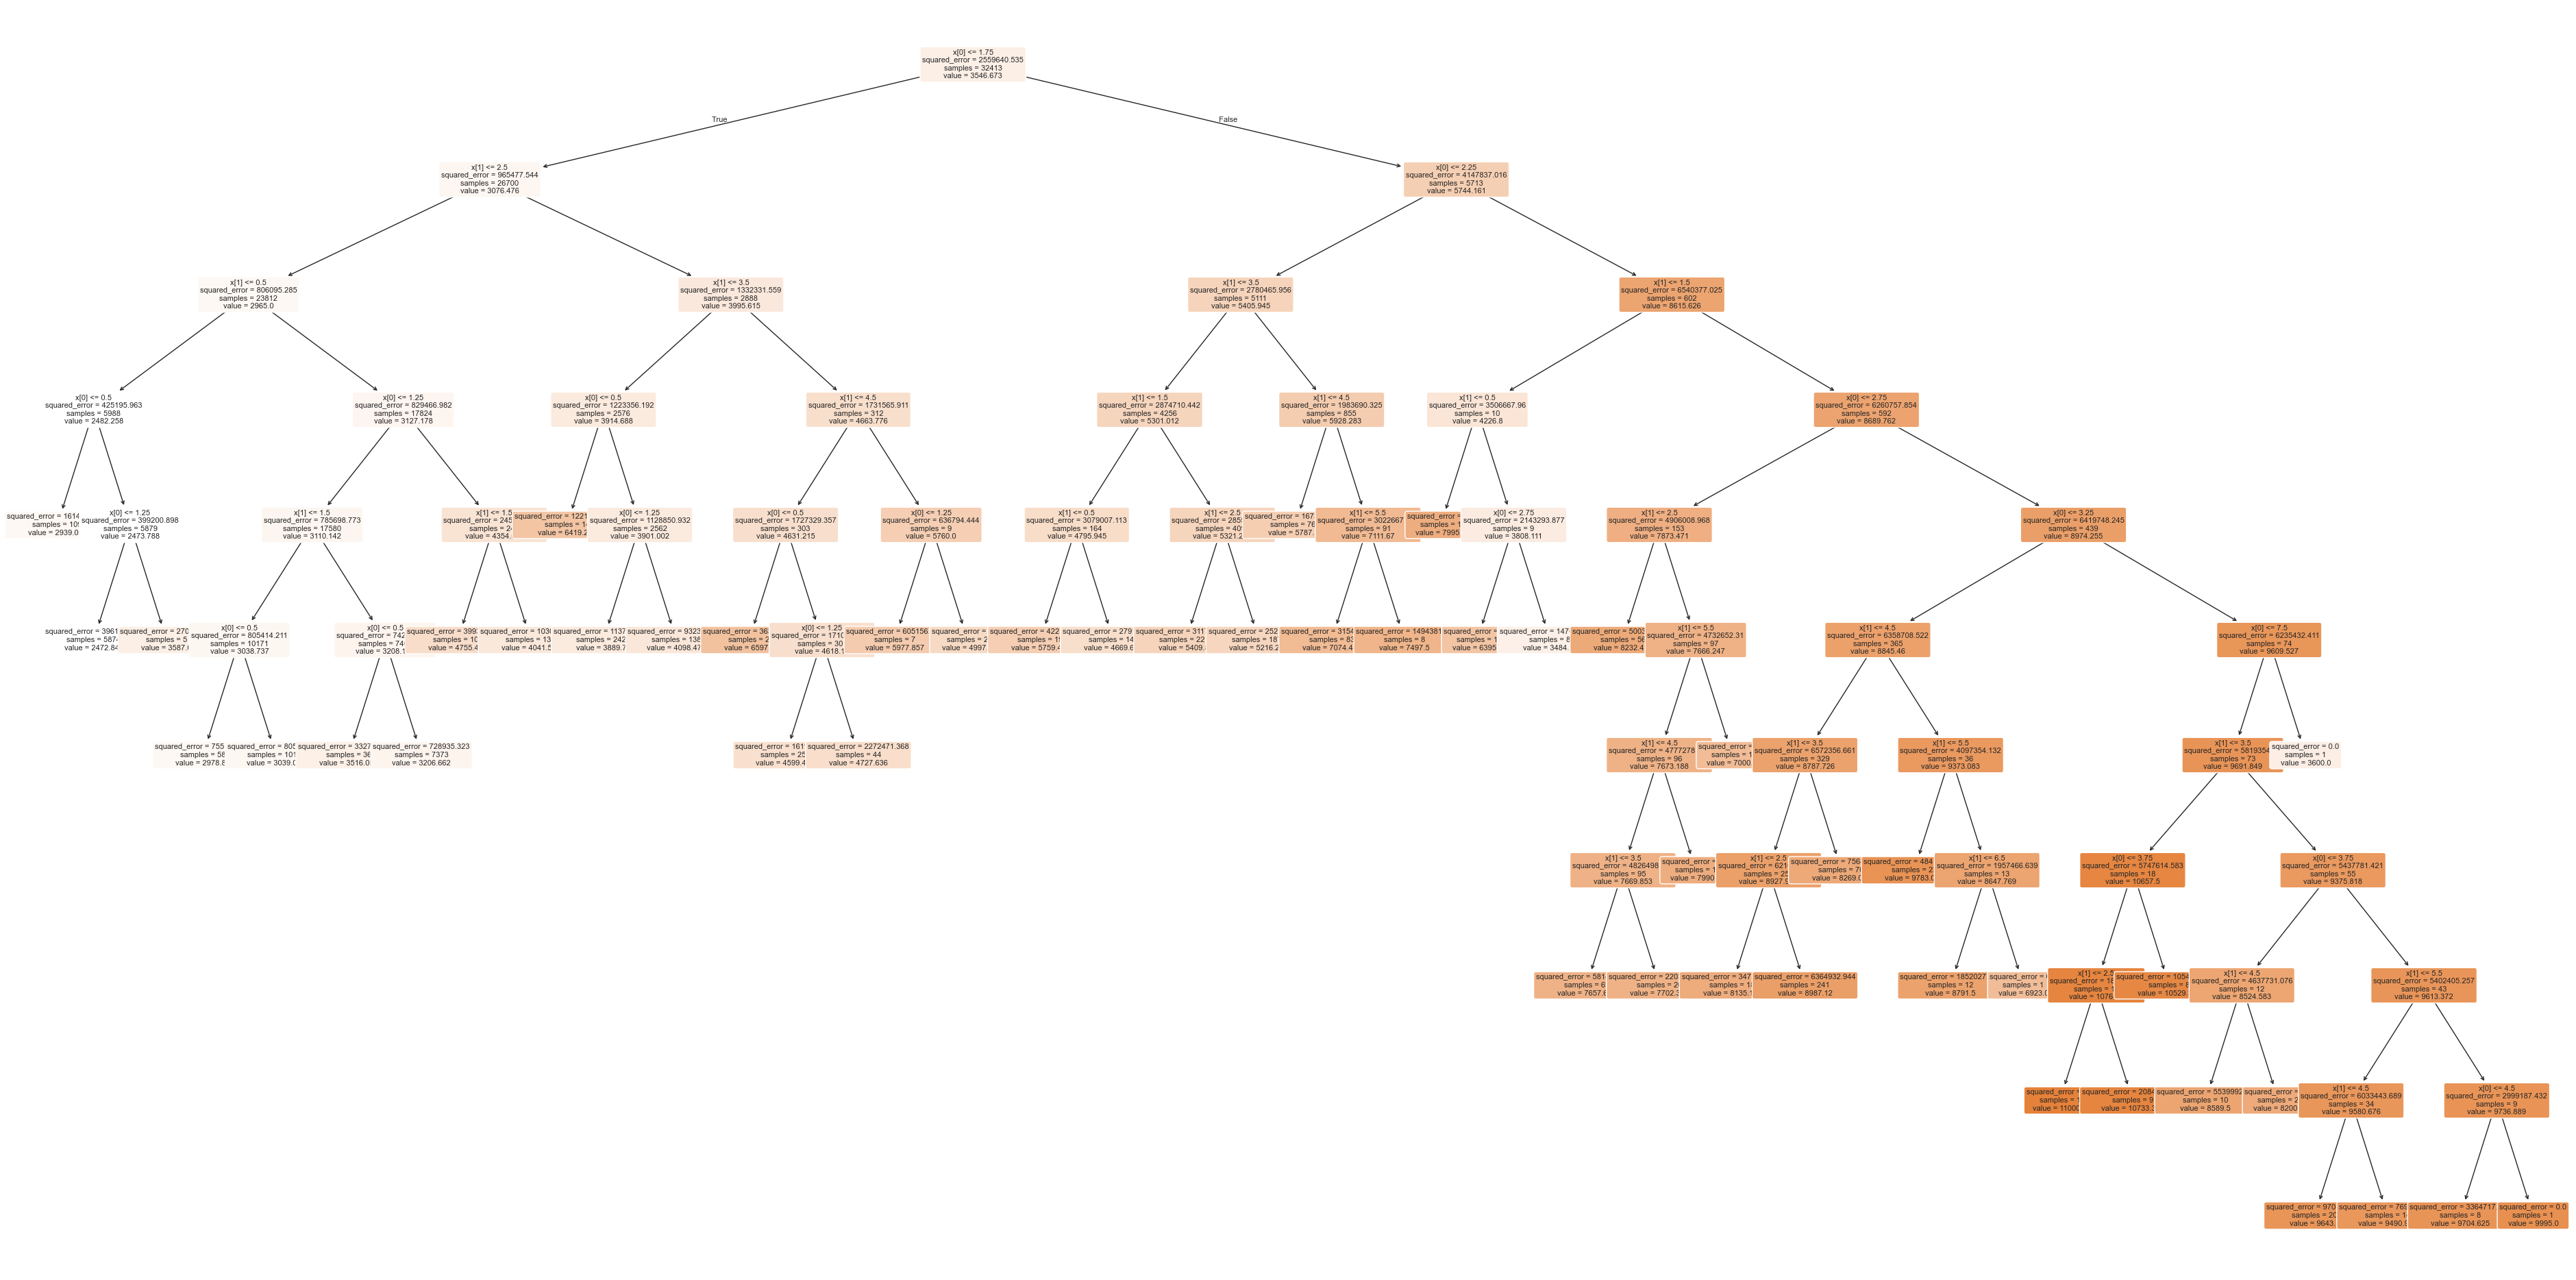

In [72]:
sns.set_theme(rc={'figure.figsize':(48,24)})
plot_tree(model_tree,
    filled=True,
    rounded=True,
    fontsize=8)

### Naiv

In [73]:
y_train.mean()*len(y_train)


np.float64(114958315.0)

In [74]:
y_mean = np.full(len(y_train),y_train.mean())
y_median = np.full(len(y_train), y_train.median())
y_mean_test = np.full(len(y_test), y_test.mean())
y_median_test = np.full(len(y_test), y_test.median())

In [75]:
result_MAE.loc[len(result_MAE)] = 'Mean', mean_absolute_error(y_train, y_mean), mean_absolute_error(y_test, y_mean_test)
result_RMSE.loc[len(result_RMSE)] = 'Mean', root_mean_squared_error(y_train, y_mean), root_mean_squared_error(y_test, y_mean_test)

result_MAE.loc[len(result_MAE)] = 'Median', mean_absolute_error(y_train, y_median), mean_absolute_error(y_test, y_median_test)
result_RMSE.loc[len(result_RMSE)] = 'Median', root_mean_squared_error(y_train, y_median), root_mean_squared_error(y_test, y_median_test)
result_MAE

,model,train,test
0,LinearRegression,786.17,784.16
1,Lasso,786.17,784.21
2,El,803.35,800.30
3,Tree,755.54,758.11
4,Mean,1142.79,1131.49
5,Median,1090.47,1077.47


In [76]:
result_RMSE

,model,train,test
0,LinearRegression,1125.63,1119.78
1,Lasso,1125.64,1119.85
2,El,1162.39,1157.29
3,Tree,1074.66,1086.31
4,Mean,1599.89,1592.96
5,Median,1648.33,1641.77
